In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from transformation import transform_csv
import os
import base64

In [2]:
class Plotter:
    def __init__(self, csv_file, epsg_from, epsg_to):
        self.csv_file = csv_file
        self.csv = transform_csv(csv_file, epsg_from, epsg_to)
        self.gdf = gpd.GeoDataFrame(
            self.csv,
            geometry=gpd.points_from_xy(self.csv["Longitude"], self.csv["Latitude"]),
        )
        self.gdf.crs = "epsg:" + str(epsg_to)
        self.bounds = self.gdf.total_bounds

    def assign_classes(self):
        num_classes = len([col for col in self.gdf.columns if "Class" in col])
        class_cols = ["Class" + str(i + 1) for i in range(num_classes)]
        self.gdf["Class"] = self.gdf[class_cols].idxmax(axis=1)

    def plot_data(self):
        num_points = len(self.gdf)
        dpi = 150 # Adjust this value as needed
        fig, ax = plt.subplots(figsize=(num_points/dpi, num_points/dpi), dpi=dpi)
        print(len(self.gdf))
        self.gdf.plot(
            column="Class", legend=False, marker=",", cmap="tab10", ax=ax
        )

        ax.set_axis_off()
        ax.set_xlim(self.gdf.geometry.x.min(), self.gdf.geometry.x.max())
        ax.set_ylim(self.gdf.geometry.y.min(), self.gdf.geometry.y.max())

        # Save the image to the 'images' folder
        image_path = os.path.join('images', 'image.png')
        plt.savefig(
            image_path,
            format="png",
            bbox_inches="tight",
            pad_inches=0,
            dpi=dpi,
            transparent=True,
        )
        plt.show()
        plt.close(fig)
        # Convert the BytesIO object to a base64 string
        # image_base64 = base64.b64encode(open(image_path, 'rb').read()).decode()
        # return image_base64
        return None

999


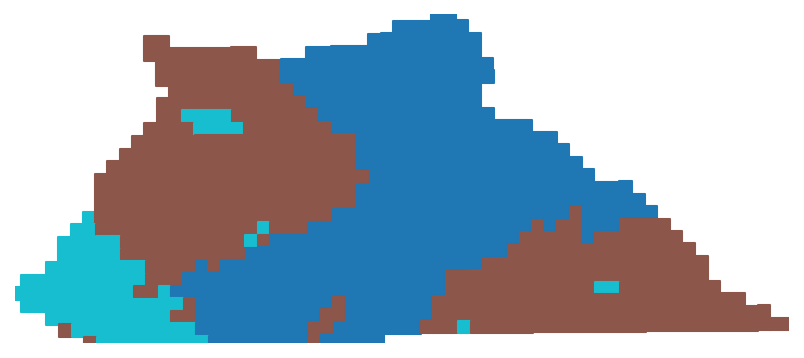

In [3]:
plotter = Plotter('upload_data/8-col-31468_test.csv', 31468, 4326)
plotter.assign_classes()
plotter.plot_data()

In [4]:
input_data = transform_csv('upload_data/8-col-31468_test.csv', 31468, 4326)
input_data['Class'] = plotter.gdf['Class']
print(input_data.head())

    Class1   Class2   Class3   Class4   Class5   Class6   Latitude  Longitude  \
0  0.10288  0.12280  0.44812  0.12411  0.10212  0.09996  51.889277  11.320169   
1  0.10640  0.12152  0.43926  0.12925  0.10089  0.10267  51.889285  11.321621   
2  0.10552  0.12627  0.43497  0.12514  0.10639  0.10171  51.888353  11.315825   
3  0.09818  0.11697  0.47549  0.11587  0.09752  0.09597  51.888361  11.317278   
4  0.09434  0.10860  0.50436  0.11032  0.09020  0.09218  51.888369  11.318730   

    Class  
0  Class3  
1  Class3  
2  Class3  
3  Class3  
4  Class3  


In [5]:
data_gdf = gpd.GeoDataFrame(
    input_data,
    geometry=gpd.points_from_xy(input_data["Longitude"], input_data["Latitude"]),
)
data_gdf.crs = "epsg:" + str(4326)

<Axes: >

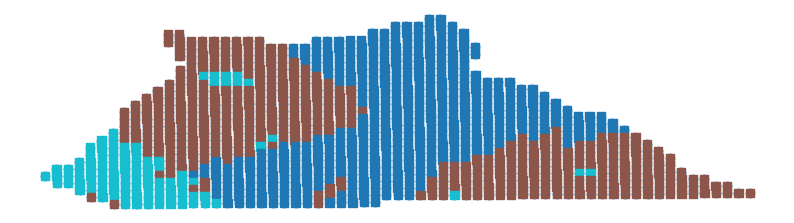

In [6]:
# Plot the data
axes = data_gdf.plot(figsize=(10, 10), aspect='equal')
# set axis off
axes.set_axis_off()
# axes.set_xlim(data_gdf.geometry.x.min(), data_gdf.geometry.x.max())
# axes.set_ylim(data_gdf.geometry.y.min(), data_gdf.geometry.y.max())
data_gdf.plot(ax=axes, column='Class', legend=False, cmap='tab10', marker=',', aspect='equal')

In [7]:
import numpy as np
# make gpd to np array
data_np = np.array(data_gdf)
print(data_np.shape)

(999, 10)


In [8]:
data_np[:,8:]

array([['Class3', <POINT (11.32 51.889)>],
       ['Class3', <POINT (11.322 51.889)>],
       ['Class3', <POINT (11.316 51.888)>],
       ...,
       ['Class3', <POINT (11.31 51.866)>],
       ['Class3', <POINT (11.312 51.866)>],
       ['Class3', <POINT (11.313 51.866)>]], dtype=object)